In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Appareil utilisé : {device.upper()}")

Appareil utilisé : CUDA


In [3]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"
print("Chargement du modèle... (cela peut prendre 2-3 minutes)")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

print("✅ Modèle FLAN-T5 chargé avec succès !")

Chargement du modèle... (cela peut prendre 2-3 minutes)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Modèle FLAN-T5 chargé avec succès !


In [4]:
from sentence_transformers import SentenceTransformer, util

sim_model = SentenceTransformer('all-MiniLM-L6-v2').to(device)
print("✅ Modèle de similarité chargé.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modèle de similarité chargé.


In [5]:
import re

def generer_paraphrase(question):
    # Dictionnaire de substitutions simples
    substitutions = [
        (r"quel est le rôle de", "À quoi sert"),
        (r"qu'est-ce qu(e|')", "Définissez"),
        (r"qu'est-ce que", "Définissez"),
        (r"rôle", "fonction"),
        (r"fonction", "rôle"),
        (r"expliquez", "Décrivez"),
        (r"décrivez", "Expliquez"),
    ]

    paraphrase = question
    for motif, remplacement in substitutions:
        paraphrase = re.sub(motif, remplacement, paraphrase, flags=re.IGNORECASE)

    if paraphrase == question:
        paraphrase = "Expliquez " + question[0].lower() + question[1:]
    return paraphrase

# Test
exemple = "Quel est le rôle de l'ADN ?"
print(f"Original : {exemple}")
print(f"Paraphrase : {generer_paraphrase(exemple)}")

Original : Quel est le rôle de l'ADN ?
Paraphrase : À quoi sert l'ADN ?


In [6]:
def repondre(question):
    inputs = tokenizer(question, return_tensors="pt", truncation=True, max_length=256).to(device)
    outputs = model.generate(**inputs, max_new_tokens=100, do_sample=False)
    reponse = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return reponse

# Test avec une question simple
test_q = "Quel est le rôle de l'ADN ?"
print(f"Question : {test_q}")
print(f"Réponse du LLM : {repondre(test_q)}")

Question : Quel est le rôle de l'ADN ?
Réponse du LLM : a phylogenetic basis


In [7]:
questions_biologie = [
    "Quel est le rôle de l'ADN ?",
    "Qu'est-ce qu'une cellule ?",
    "Quel est le rôle des mitochondries ?",
    "Où se produit la photosynthèse ?",
    "À quoi servent les anticorps ?",
    "Quelle est la différence entre l'ADN et l'ARN ?",
    "Qu'est-ce qu'un gène ?",
    "Combien de chromosomes possède une cellule humaine ?",
    "Quel est le rôle du noyau ?",
    "Comment se reproduisent les bactéries ?"
]
print(f"{len(questions_biologie)} questions chargées.")
for i, q in enumerate(questions_biologie, 1):
    print(f"{i}. {q}")

10 questions chargées.
1. Quel est le rôle de l'ADN ?
2. Qu'est-ce qu'une cellule ?
3. Quel est le rôle des mitochondries ?
4. Où se produit la photosynthèse ?
5. À quoi servent les anticorps ?
6. Quelle est la différence entre l'ADN et l'ARN ?
7. Qu'est-ce qu'un gène ?
8. Combien de chromosomes possède une cellule humaine ?
9. Quel est le rôle du noyau ?
10. Comment se reproduisent les bactéries ?


In [8]:
import pandas as pd

resultats = []

for q_originale in questions_biologie:
    q_paraphrase = generer_paraphrase(q_originale)
    rep_orig = repondre(q_originale)
    rep_para = repondre(q_paraphrase)

    emb_orig = sim_model.encode(rep_orig, convert_to_tensor=True)
    emb_para = sim_model.encode(rep_para, convert_to_tensor=True)
    similarite = util.pytorch_cos_sim(emb_orig, emb_para).item()

    resultats.append({
        "question_originale": q_originale,
        "paraphrase": q_paraphrase,
        "reponse_originale": rep_orig,
        "reponse_paraphrase": rep_para,
        "similarite": round(similarite, 4)
    })

    print(f"\n--- {q_originale} ---")
    print(f"Paraphrase : {q_paraphrase}")
    print(f"Réponse originale : {rep_orig}")
    print(f"Réponse paraphrase : {rep_para}")
    print(f"Similarité : {similarite:.4f}")

print("\n✅ Évaluation terminée.")


--- Quel est le rôle de l'ADN ? ---
Paraphrase : À quoi sert l'ADN ?
Réponse originale : a phylogenetic basis
Réponse paraphrase : a synapse
Similarité : 0.2129

--- Qu'est-ce qu'une cellule ? ---
Paraphrase : Définissezune cellule ?
Réponse originale : a cell
Réponse paraphrase : asexual
Similarité : 0.1813

--- Quel est le rôle des mitochondries ? ---
Paraphrase : À quoi serts mitochondries ?
Réponse originale : Mitochondrial
Réponse paraphrase : a synapse
Similarité : 0.2810

--- Où se produit la photosynthèse ? ---
Paraphrase : Expliquez où se produit la photosynthèse ?
Réponse originale : a synapse
Réponse paraphrase : a synapse
Similarité : 1.0000

--- À quoi servent les anticorps ? ---
Paraphrase : Expliquez à quoi servent les anticorps ?
Réponse originale : a savagery
Réponse paraphrase : a symphony orchestra
Similarité : 0.1230

--- Quelle est la différence entre l'ADN et l'ARN ? ---
Paraphrase : Expliquez quelle est la différence entre l'ADN et l'ARN ?
Réponse originale : a 

In [9]:
df = pd.DataFrame(resultats)
df

,question_originale,paraphrase,reponse_originale,reponse_paraphrase,similarite
0,Quel est le rôle de l'ADN ?,À quoi sert l'ADN ?,a phylogenetic basis,a synapse,0.2129
1,Qu'est-ce qu'une cellule ?,Définissezune cellule ?,a cell,asexual,0.1813
2,Quel est le rôle des mitochondries ?,À quoi serts mitochondries ?,Mitochondrial,a synapse,0.2810
3,Où se produit la photosynthèse ?,Expliquez où se produit la photosynthèse ?,a synapse,a synapse,1.0000
4,À quoi servent les anticorps ?,Expliquez à quoi servent les anticorps ?,a savagery,a symphony orchestra,0.1230
5,Quelle est la différence entre l'ADN et l'ARN ?,Expliquez quelle est la différence entre l'ADN...,a chromosome,RNA,0.3457
6,Qu'est-ce qu'un gène ?,Définissezun gène ?,a gene,genus,0.3060
7,Combien de chromosomes possède une cellule hum...,Expliquez combien de chromosomes possède une c...,chromosomes,chromosomes,1.0000
8,Quel est le rôle du noyau ?,Expliquez quel est le rôle du noyau ?,a symphony,a symphony,1.0000
9,Comment se reproduisent les bactéries ?,Expliquez comment se reproduisent les bactéries ?,Les bactéries sont reproduisés ?,et et et et et et et et et et et et et et et e...,0.0085


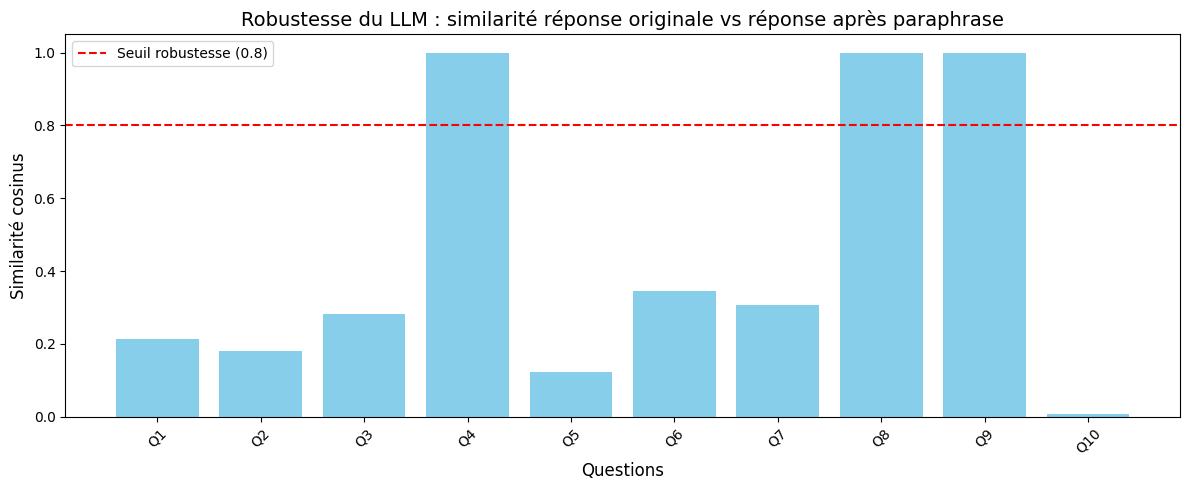

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(df)), df["similarite"], color='skyblue')
plt.axhline(y=0.8, color='r', linestyle='--', label='Seuil robustesse (0.8)')
plt.xlabel("Questions", fontsize=12)
plt.ylabel("Similarité cosinus", fontsize=12)
plt.title("Robustesse du LLM : similarité réponse originale vs réponse après paraphrase", fontsize=14)
plt.xticks(range(len(df)), [f"Q{i+1}" for i in range(len(df))], rotation=45)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Sauvegarde dans ton Google Drive
save_path = "/content/drive/MyDrive/llm_robustesse_evaluation.csv"
df.to_csv(save_path, index=False)
print(f"✅ Résultats sauvegardés dans : {save_path}")

# Sauvegarde locale (dans l'environnement Colab)
df.to_csv("resultats_robustesse.csv", index=False)
print("✅ Sauvegarde locale : resultats_robustesse.csv")

✅ Résultats sauvegardés dans : /content/drive/MyDrive/llm_robustesse_evaluation.csv
✅ Sauvegarde locale : resultats_robustesse.csv
